# Κουρτέσης Δημήτρης - Toy Monte-Carlo - Ιονιστικά Σωματίδια σε Σπινθηριστή-Ίνα

## Δημιουργία φωτονίων από διέλευση ιονιστικών σωματιδίων σε σπινθηριστή-ίνα

Ιονιστικά σωματίδια διαπερνούν έναν σπινθηριστή-ίνα κάθετα στη διεύθυνση του άξονα της ίνας, ο οποίος είναι παράλληλος του $z$-άξονα.

Φωτόνια δημιουργούνται με ισοτροπική γωνιακή κατανομή στο χώρο. Τα φωτόνια ανακλώνται από την εσωτερική επιφάνεια της ίνας εάν η γωνία πρόσπτωσης ως προς την κάθετο στην επιφάνεια είναι μεγαλύτερη από

$$
\beta_0 = 60^\circ
$$

Για μικρότερες γωνίες πρόσπτωσης, το φωτόνιο χάνεται.

Θέλουμε να εκτιμήσουμε την εξάρτηση του πλήθους των φωτονίων που εγκλωβίζονται εντός του σπινθηριστή από το σημείο εισόδου του ιονιστικού σωματιδίου. Κάθε σωματίδιο ακολουθεί τροχιά κατά την $y$-διεύθυνση και σε απόσταση $x$ από τον άξονα της ίνας.

## Υπολογισμός γεωμετρικής αποδοχής σπινθηριστή-ίνας

- Θεωρήστε την ακτίνα της ίνας ίση με μονάδα:
  $$
  R = 1
  $$

- Δημιουργήστε ένα φωτόνιο στη θέση $(x,y)$ με ομοιόμορφη κατανομή εντός του τετραγώνου:
  $$
  0 < x < 1, \quad 0 < y < 1
  $$

- Υπολογίστε:
  $$
  r^2 = x^2 + y^2
  $$
  Εάν:
  $$
  r^2 > 1
  $$
  απορρίψτε το γεγονός.

- Επιλέξτε αζιμουθιακή γωνία $\phi$ για την κατεύθυνση του φωτονίου:
  $$
  0 < \phi < 2\pi
  $$
  με ομοιόμορφη κατανομή.

- Υπολογίστε τη γωνία $\alpha$, που είναι η προβολή της γωνίας πρόσπτωσης στα τοιχώματα της ίνας:
  $$
  \sin \alpha = r \sin \phi
  $$

- Επιλέξτε πολική γωνία $\theta$ για τη διεύθυνση του φωτονίου:
  $$
  0 < \cos\theta < 1
  $$
  όπου η $\cos\theta$ ακολουθεί ομοιόμορφη κατανομή.

- Υπολογίστε τη γωνία $\beta$ ως προς την κάθετο στην εσωτερική επιφάνεια της ίνας:
  $$
  \cos \beta = \sin \theta \, \cos \alpha
  $$

- Απορρίψτε το φωτόνιο αν:
  $$
  \beta < \beta_0
  $$

- Αποθηκεύστε την τιμή $x$ για τις επιτυχημένες προσπάθειες.

- Δημιουργήστε ιστόγραμμα με τις τιμές του $x$ για τις επιτυχημένες προσπάθειες και κανονικοποιήστε ως προς το συνολικό πλήθος των προσπαθειών.

<div style="text-align: center;">
    <img src="optical_fiber.png" width="400">
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

rcparams = {
           "savefig.bbox" : "tight",
           "agg.path.chunksize" : 10000,
           "font.family" : "serif",
           "font.size" : 22,
           "legend.fontsize" : 16,
           "legend.loc" : "upper right",
           "mathtext.fontset" : "stix",
           "text.usetex" : True,

           # Set x axis
           "xtick.direction" : "in",
           "xtick.major.size" : 6,
           "xtick.major.width" : 1,
           "xtick.minor.size" : 3,
           "xtick.minor.width" : 1,
           "xtick.minor.visible" : True,
           "xtick.top" : True,

           # Set y axis
           "ytick.direction" : "in",
           "ytick.major.size" : 6,
           "ytick.major.width" : 1,
           "ytick.minor.size" : 3,
           "ytick.minor.width" : 1,
           "ytick.minor.visible" : True,
           "ytick.right" : True,

           # Set line widths
           "axes.linewidth" : 0.5,
           "grid.linewidth" : 0.5,
           "lines.linewidth" : 1.,

           # Grid lines
           "axes.grid" : True,
           "axes.axisbelow" : True,
           "grid.linestyle" : "--",
           "grid.color" : "k",
           "grid.alpha" : 0.5,
           "grid.linewidth" : 0.5,

           # Legend
           "legend.frameon" : True,
           "legend.framealpha" : 1.0,
           "legend.fancybox" : True,
           "legend.numpoints" : 1,

           # Fontsizes
           "xtick.labelsize" : 16,
           "ytick.labelsize" : 16,
           "legend.fontsize" : 16,
           "legend.title_fontsize" : 16,
           "axes.titlesize" : 16,
           "axes.labelsize" : 16,
           }

mpl.rcParams.update(rcparams)

In [2]:
class ScintillatorFiberMC:
    def __init__(self,
                 R=1.0,
                 beta0_deg=60,
                 n_events=100000,
                 seed=None):
        """
        Monte Carlo simulation for photon trapping in scintillator fiber.
        
        Parameters:
        -----------
        R : float
            Fiber radius
        beta0_deg : float
            Critical angle in degrees
        n_events : int
            Number of Monte Carlo trials
        seed : int or None
            Random seed
        """
        self.R = R
        self.beta0 = np.deg2rad(beta0_deg)
        self.n_events = n_events
        
        self.rng = np.random.default_rng(seed)

        # storage
        self.x_hits = []
        self.accepted = 0

    # -----------------------------
    # Geometry sampling
    # -----------------------------
    def sample_position(self):
        """
        Sample (x,y) uniformly in unit square and reject outside circle.
        """
        x = self.rng.uniform(0, 1)
        y = self.rng.uniform(0, 1)

        r2 = x**2 + y**2
        if r2 > self.R**2:
            return None  # reject

        return x, y, np.sqrt(r2)

    # -----------------------------
    # Photon direction sampling
    # -----------------------------
    def sample_angles(self):
        """
        Sample phi uniform in [0,2pi], cos(theta) uniform in [0,1]
        """
        phi = self.rng.uniform(0, 2*np.pi)
        cos_theta = self.rng.uniform(0, 1)
        theta = np.arccos(cos_theta)

        return theta, phi

    # -----------------------------
    # Physics conditions
    # -----------------------------
    def compute_alpha(self, r, phi):
        """
        sin(alpha) = r sin(phi)
        """
        val = r * np.sin(phi)
        val = np.clip(val, -1, 1)
        return np.arcsin(val)

    def compute_beta(self, theta, alpha):
        """
        cos(beta) = sin(theta) sin(alpha)
        """
        val = np.sin(theta) * np.cos(alpha)
        val = np.clip(val, -1, 1)
        return np.arccos(val)

    def is_accepted(self, beta):
        return beta >= self.beta0

    # -----------------------------
    # Main simulation
    # -----------------------------
    def run(self):
        for _ in range(self.n_events):

            sample = self.sample_position()
            if sample is None:
                continue

            x, y, r = sample

            theta, phi = self.sample_angles()

            alpha = self.compute_alpha(r, phi)
            beta = self.compute_beta(theta, alpha)

            if self.is_accepted(beta):
                self.accepted += 1
                self.x_hits.append(x)

        self.x_hits = np.array(self.x_hits)
        return self.x_hits

    # -----------------------------
    # Results
    # -----------------------------
    def efficiency(self):
        return self.accepted / self.n_events

    def plot_histogram(self, bins=50):

        counts, bin_edges = np.histogram(self.x_hits, bins=bins)

        # normalize by total trials
        counts = counts / self.n_events

        plt.bar(
            bin_edges[:-1],
            counts,
            width=np.diff(bin_edges),
            align='edge',
            alpha=0.8
        )

        plt.xlabel("x (entry position)")
        plt.ylabel("Fraction of total trials per bin")
        plt.title("Accepted photons vs entry position")

        plt.grid(False)
        plt.show()

    def plot_geometry_example(self, n_rays=20, seed=0):

        rng = np.random.default_rng(seed)

        fig, ax = plt.subplots()

        # fiber boundary
        circle = plt.Circle((0, 0), self.R, fill=False, linewidth=1.5)
        ax.add_patch(circle)

        xs, ys = [], []
        u, v = [], []

        count = 0

        while count < n_rays:

            sample = self.sample_position()
            if sample is None:
                continue

            x, y, r = sample

            theta, phi = self.sample_angles()

            dx = np.cos(phi)
            dy = np.sin(phi)

            xs.append(x)
            ys.append(y)
            u.append(dx)
            v.append(dy)

            count += 1

        
        ax.quiver(
            xs, ys, u, v,
            angles='xy',
            scale_units='xy',
            scale=5,
            width=0.003,
            alpha=0.6
        )

        ax.scatter(xs, ys, s=8, color='black', alpha=0.7)

        ax.set_aspect("equal")
        
        ax.set_title("Generated Photons")
        ax.set_xlim(-self.R*1.1-0.1, self.R*1.1+0.1)
        ax.set_ylim(-self.R*1.1-0.1, self.R*1.1+0.1)
        ax.grid(True, axis='x', alpha=0.3)
        ax.grid(True, axis='y', alpha=0.3)

        plt.show()

    def plot_accept_reject(self, n_show=5000):

        accepted_color = "#1F9D8A"   # strong soft teal
        rejected_color = "#5C677D"   # deep blue-gray
        
        fig, ax = plt.subplots()
        circle = plt.Circle((0, 0), self.R, fill=False)
        ax.add_patch(circle)

        shown = 0

        while shown < n_show:
            sample = self.sample_position()
            if sample is None:
                continue

            x, y, r = sample
            theta, phi = self.sample_angles()

            alpha = self.compute_alpha(r, phi)
            beta = self.compute_beta(theta, alpha)

            if self.is_accepted(beta):
                ax.scatter(x, y, color=accepted_color, s=6, alpha=0.7)
            else:
                ax.scatter(x, y, color=rejected_color, s=6)

            shown += 1

        ax.set_aspect("equal")
        ax.set_title("Accepted (Green) vs Rejected (Gray)")
        ax.grid(False)
        ax.set_xlim(0, 1.05)
        ax.set_ylim(0, 1.05)
        ax.minorticks_off()
        plt.show()

Efficiency: 0.19643


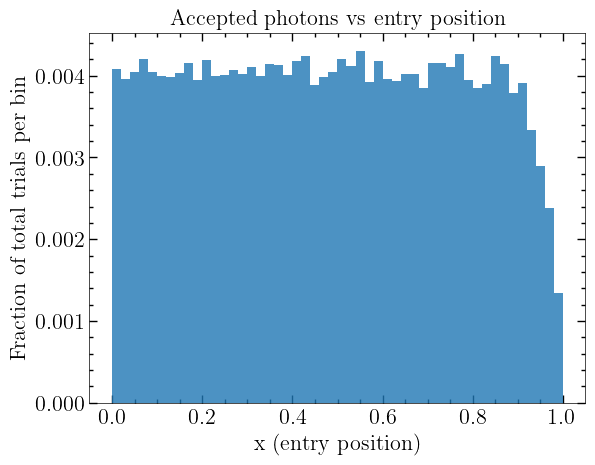

In [3]:
sim = ScintillatorFiberMC(
    R=1.0,
    beta0_deg=60,
    n_events=200000,
    seed=42
)

sim.run()

print("Efficiency:", sim.efficiency())

sim.plot_histogram()

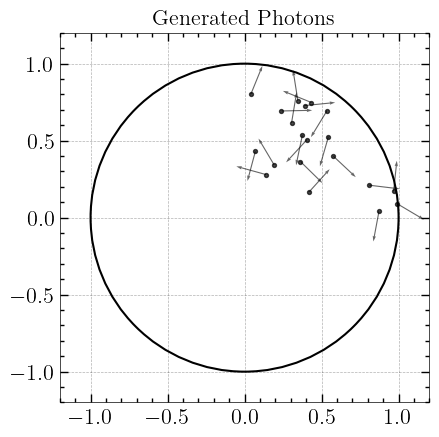

In [4]:
sim.plot_geometry_example()

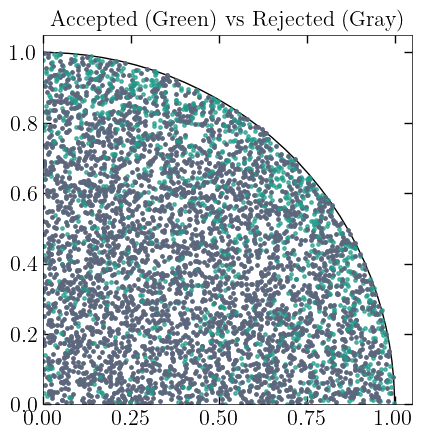

In [5]:
sim.plot_accept_reject()